# Análisis de grupo de Whatsapp

##### En esta libreta, se analizará el comportamiento de un grupo de whatsapp dedicado a una relación entre una área de desarrollo y una área operativa en gobierno del estado. La idea es desubrir datos curiosos y patrones de comportamiento contados por los datos mismos.

- Hecho por: Carlos Sotomayor

---

## Importación de librerías

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
# plt.style.use('ggplot')
import seaborn as sns
import requests
import wordcloud
import spacy
import os
import re
import squarify
from wordcloud import WordCloud
from collections import Counter
from bs4 import BeautifulSoup
from pathlib import Path
from dotenv import load_dotenv
from matplotlib.patches import Patch
from matplotlib.dates import DateFormatter

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

In [4]:
def getListaPokemon(ruta): #   Acotamiento de lista de nombres de pokémon
    df = pd.read_csv(ruta, usecols=[1])
    df = df.iloc[:151,:]
    return df

In [5]:
def mapear_nombres(df, mapeo, semilla=42): # función de mapeado con una semilla aleatoria
    rng = np.random.default_rng(seed=semilla)

    # Obtener nombres únicos
    nombres_unicos = df["nombre"].dropna().unique()

    # Obtener Pokémon disponibles
    pokemons = mapeo.dropna().to_numpy()

    # Validar que haya suficientes Pokémon
    if len(nombres_unicos) > len(pokemons):
        raise ValueError(
            f"Hay {len(nombres_unicos)} nombres únicos, "
            f"pero solo {len(pokemons)} Pokémon disponibles."
        )

    # Seleccionar Pokémon aleatoriamente sin repetición
    pokemons_aleatorios = rng.choice(
        pokemons,
        size=len(nombres_unicos),
        replace=False
    )

    # Crear diccionario:
    # nombre original -> Pokémon
    diccionario_mapeo = dict(
        zip(nombres_unicos, pokemons_aleatorios)
    )

    # Crear copia
    df_resultado = df.copy()

    # Mapear columna nombre
    df_resultado["nombre"] = (
        df_resultado["nombre"]
        .map(diccionario_mapeo)
    )

    # Función para reemplazar menciones dentro del mensaje
    def reemplazar_mencion(match):
        nombre_mencionado = match.group(1).strip()

        # Buscar ese nombre en el diccionario
        pokemon = diccionario_mapeo.get(nombre_mencionado)

        if pokemon is not None:
            return f"@{pokemon}"

        # Si no encontramos equivalencia, conservar la mención
        return match.group(0)

    # Reemplazar menciones tipo:
    df_resultado["mensaje"] = (
        df_resultado["mensaje"]
        .fillna("")
        .apply(
            lambda texto: re.sub(
                r"@\u2068(.*?)\u2069",
                reemplazar_mencion,
                texto
            )
        )
    )

    return df_resultado

In [116]:
# def limpiar_menciones(df):
#     df = df.copy()

#     df["mensaje"] = df["mensaje"].str.replace(
#         r"@.*?",
#         "@Mención",
#         regex=True
#     )

#     return df

## Carga y preprocesamiento del dataframe

In [6]:
# Raíz del proyecto
PROJECT_ROOT = Path("..").resolve()

# Cargar .env ubicado en la raíz
load_dotenv(PROJECT_ROOT / ".env")

# Obtener rutas relativas desde variables de entorno
data = PROJECT_ROOT / os.getenv("WHATSAPP_DATA")
pkmn_map = PROJECT_ROOT / os.getenv("POKEMON_MAP")

#   Patrones regex de captura
patron = re.compile(
    r"^"
    r"(\d{1,2}/\d{1,2}/\d{2,4}),\s*"   # fecha
    r"(\d{1,2}:\d{2})\s*"              # hora
    r"([ap]\.?\s*m\.?)\s*"             # a. m. / p. m.
    r"-\s*"
    r"([^:]+):\s*"                      # nombre
    r"(.*)$",                           # mensaje
    re.IGNORECASE
)

registros = []
registro_actual = None

with open(data, "r", encoding="utf-8") as f:
    for linea in f:

        linea = (
            linea
            .replace("\u200e", "")
            .replace("\u202f", " ")
            .replace("\u00a0", " ")
            .rstrip("\n")
        )

        match = patron.match(linea)

        if match:
            # Guardar mensaje anterior antes de iniciar uno nuevo
            if registro_actual is not None:
                registros.append(registro_actual)

            fecha, hora, periodo, nombre, mensaje = match.groups()

            registro_actual = {
                "fecha": fecha,
                "hora": hora,
                "periodo": periodo.strip(),
                "nombre": nombre.strip(),
                "mensaje": mensaje.strip()
            }

        else:
            # Línea adicional del mensaje anterior
            if registro_actual is not None:
                registro_actual["mensaje"] += "\n" + linea.strip()

# Guardar el último mensaje
if registro_actual is not None:
    registros.append(registro_actual)

df = pd.DataFrame(registros)
df.shape

(1053, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   fecha    1053 non-null   str  
 1   hora     1053 non-null   str  
 2   periodo  1053 non-null   str  
 3   nombre   1053 non-null   str  
 4   mensaje  1053 non-null   str  
dtypes: str(5)
memory usage: 41.3 KB


In [8]:
mapeo = getListaPokemon(pkmn_map)
mapeo.head()

,en
0,Bulbasaur
1,Ivysaur
2,Venusaur
3,Charmander
4,Charmeleon


In [9]:
df_map = mapear_nombres(
    df,
    mapeo,
    semilla=42
)
df_map.head()

,fecha,hora,periodo,nombre,mensaje
0,26/3/26,2:42,p. m.,[Mewtwo],"Y otra cosa @['Hitmonlee'], @['Weedle'] está i..."
1,26/3/26,2:42,p. m.,[Mewtwo],<Multimedia omitido>
2,26/3/26,2:44,p. m.,[Mewtwo],Tenemos 2 dudas:\n1) Quiere ese funcionamiento...
3,26/3/26,2:51,p. m.,[Hitmonlee],"No, los inactivos no me sirven para ningun rep..."
4,26/3/26,3:00,p. m.,[Hitmonlee],Respecto a los códigos que fueron *inhabilitad...


In [10]:
df_map["nombre"] = df_map["nombre"].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.size == 1 else str(x))
df_map.shape

(1053, 5)

In [11]:
# Normalizar a.m. / p.m.
periodo_normalizado = (
    df_map["periodo"]
    .str.lower()
    .str.replace(".", "", regex=False)
    .str.replace("\u202f", "", regex=False)  # espacio angosto Unicode
    .str.replace(" ", "", regex=False)
)

# Crear datetime
df_map["datetime"] = pd.to_datetime(
    df_map["fecha"] + " " +
    df_map["hora"] + " " +
    periodo_normalizado,
    format="%d/%m/%y %I:%M %p"
)

# Asignar zona horaria de Sonora
df_map["datetime"] = (
    df_map["datetime"]
    .dt.tz_localize("America/Hermosillo")
)

df_map.head()

,fecha,hora,periodo,nombre,mensaje,datetime
0,26/3/26,2:42,p. m.,Mewtwo,"Y otra cosa @['Hitmonlee'], @['Weedle'] está i...",2026-03-26 14:42:00-07:00
1,26/3/26,2:42,p. m.,Mewtwo,<Multimedia omitido>,2026-03-26 14:42:00-07:00
2,26/3/26,2:44,p. m.,Mewtwo,Tenemos 2 dudas:\n1) Quiere ese funcionamiento...,2026-03-26 14:44:00-07:00
3,26/3/26,2:51,p. m.,Hitmonlee,"No, los inactivos no me sirven para ningun rep...",2026-03-26 14:51:00-07:00
4,26/3/26,3:00,p. m.,Hitmonlee,Respecto a los códigos que fueron *inhabilitad...,2026-03-26 15:00:00-07:00


In [12]:
df_map.drop(columns=['fecha', 'hora', 'periodo'], inplace=True)

In [13]:
df_map['hora'] = df_map['datetime'].dt.hour
df_map['Fecha'] = df_map['datetime'].dt.date
df_map.head()

,nombre,mensaje,datetime,hora,Fecha
0,Mewtwo,"Y otra cosa @['Hitmonlee'], @['Weedle'] está i...",2026-03-26 14:42:00-07:00,14,2026-03-26
1,Mewtwo,<Multimedia omitido>,2026-03-26 14:42:00-07:00,14,2026-03-26
2,Mewtwo,Tenemos 2 dudas:\n1) Quiere ese funcionamiento...,2026-03-26 14:44:00-07:00,14,2026-03-26
3,Hitmonlee,"No, los inactivos no me sirven para ningun rep...",2026-03-26 14:51:00-07:00,14,2026-03-26
4,Hitmonlee,Respecto a los códigos que fueron *inhabilitad...,2026-03-26 15:00:00-07:00,15,2026-03-26


In [14]:
df_map.info()

<class 'pandas.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype                             
---  ------    --------------  -----                             
 0   nombre    1053 non-null   str                               
 1   mensaje   1053 non-null   str                               
 2   datetime  1053 non-null   datetime64[us, America/Hermosillo]
 3   hora      1053 non-null   int32                             
 4   Fecha     1053 non-null   object                            
dtypes: datetime64[us, America/Hermosillo](1), int32(1), object(1), str(2)
memory usage: 37.1+ KB


In [15]:
print(f'Periodo de inicio del análisis: {df_map['datetime'].min()}')
print(f'Periodo de cierre del análisis: {df_map['datetime'].max()}')

Periodo de inicio del análisis: 2026-03-26 14:42:00-07:00
Periodo de cierre del análisis: 2026-09-25 15:52:00-07:00


---

## Preguntas de interés

### _1.0. ¿Quién es el usuario que más mensajes envía?_

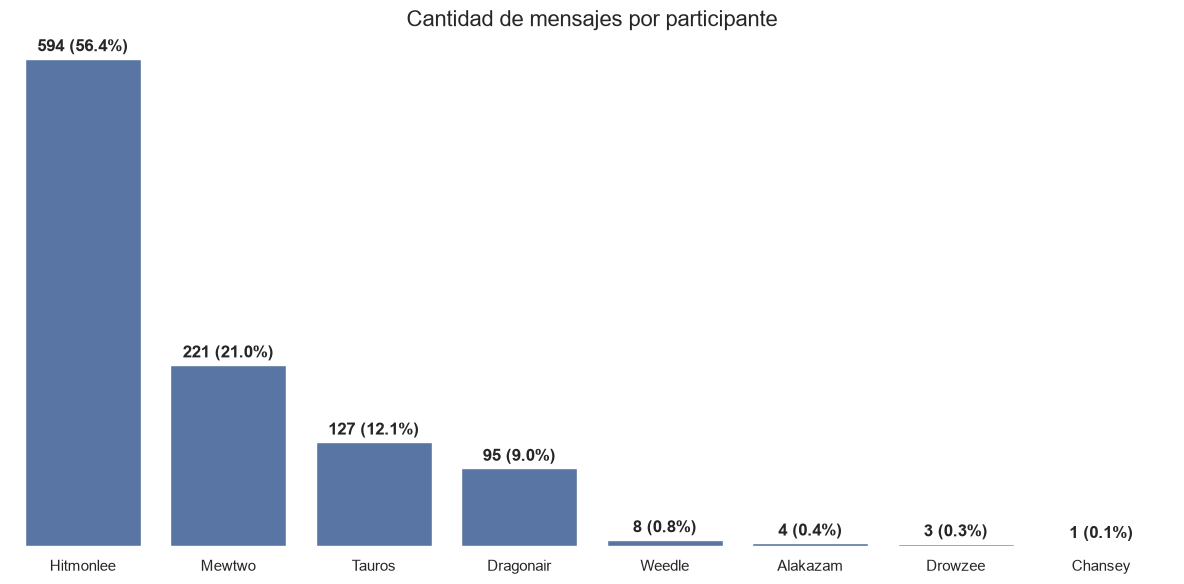

In [16]:
conteo = (df_map["nombre"].value_counts())
conteo_porc = (df_map["nombre"].value_counts(normalize=True))

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=conteo.index,
    y=conteo.values
)

labels = [
    f"{cantidad} ({porcentaje:.1%})"
    for cantidad, porcentaje in zip(conteo.values, conteo_porc.values)
]

# Agregar data labels
ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=3,
    fontweight="bold"
)

# Eliminar títulos de los ejes
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])

sns.despine(
    left=True,
    bottom=True
)

plt.title("Cantidad de mensajes por participante",
          fontsize=16)

plt.tight_layout()
plt.show()

En el periodo analizado, se observa con diferencia que `Hitmonlee` es el usuario más activo con el chat, siendo que el segundo lugar no llega ni a la mitad de los mensajes que ha mandado `Hitmonlee`... En sí, se ve que entre este usuario y `Mewtwo` conforman más del  75% de las interacciones de este chat.

## _2.0. ¿Cuál es la frecuencia promedio de palabras por mensaje de texto de cada usuario?_

In [17]:
# Contar palabras por mensaje
df_map["num_palabras"] = (
    df_map["mensaje"]
    .fillna("")
    .str.split()
    .str.len()
)

df_map.head()


,nombre,mensaje,datetime,hora,Fecha,num_palabras
0,Mewtwo,"Y otra cosa @['Hitmonlee'], @['Weedle'] está i...",2026-03-26 14:42:00-07:00,14,2026-03-26,17
1,Mewtwo,<Multimedia omitido>,2026-03-26 14:42:00-07:00,14,2026-03-26,2
2,Mewtwo,Tenemos 2 dudas:\n1) Quiere ese funcionamiento...,2026-03-26 14:44:00-07:00,14,2026-03-26,60
3,Hitmonlee,"No, los inactivos no me sirven para ningun rep...",2026-03-26 14:51:00-07:00,14,2026-03-26,14
4,Hitmonlee,Respecto a los códigos que fueron *inhabilitad...,2026-03-26 15:00:00-07:00,15,2026-03-26,109


In [ ]:
# fila_max = df_map[df_map["num_palabras"] == df_map["num_palabras"].max()]

# print(fila_max["mensaje"].iloc[0])

In [18]:
#   Eliminar el <Multimedia omitido> para que no afecte al conteo de palabras por pensaje
df_texto = df_map[
    df_map["mensaje"].ne("<Multimedia omitido>")
].copy()

In [19]:
estadisticas_palabras = (
    df_texto
    .groupby("nombre")["num_palabras"]
    .agg(
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        total="sum"
    )
    .sort_values("promedio", ascending=False)
    .round(2)
)


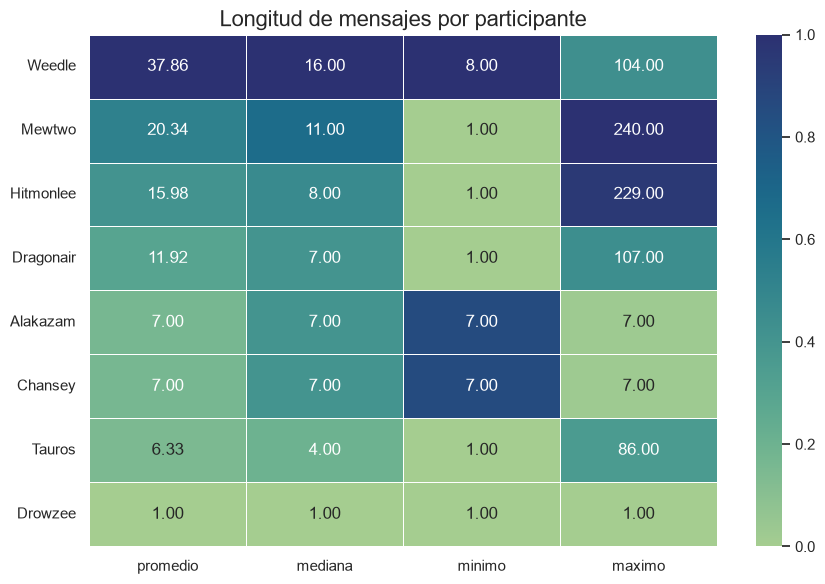

In [20]:
columnas = ["promedio", "mediana", "minimo", "maximo"]

estadisticas_heatmap = estadisticas_palabras[columnas]

estadisticas_norm = (
    estadisticas_heatmap - estadisticas_heatmap.min()
) / (
    estadisticas_heatmap.max() - estadisticas_heatmap.min()
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    estadisticas_norm,
    annot=estadisticas_heatmap,
    fmt=".2f",
    cmap="crest",
    linewidths=0.5
)

plt.xlabel("")
plt.ylabel("")
plt.title("Longitud de mensajes por participante", fontsize=16)

plt.tight_layout()
plt.show()

Si bien `Weedle` tiene el récord de mayor cantidad de palabras por mensaje, en la tabla del punto 1.0. se puede corroborar que su muestra es muy reducida, pues solo ha mandado 8 mensajes en total y ha escrito 265 palabras; por ota parte, el segundo lugar se lo lleva `Mewtwo`, quien logra llegar a las 20.34 palabras promedio por mensaje y tiene al menos un 20% de participación en el chat. Se podría decir que `Mewtwo` tiene el primer lugar gracias a su muestra más distribuida.

### _3.0. ¿Cuál es el usuario que más palabras envía? ¿Y el que envía más emojis? ¿Y el que envía más *stickers*?_

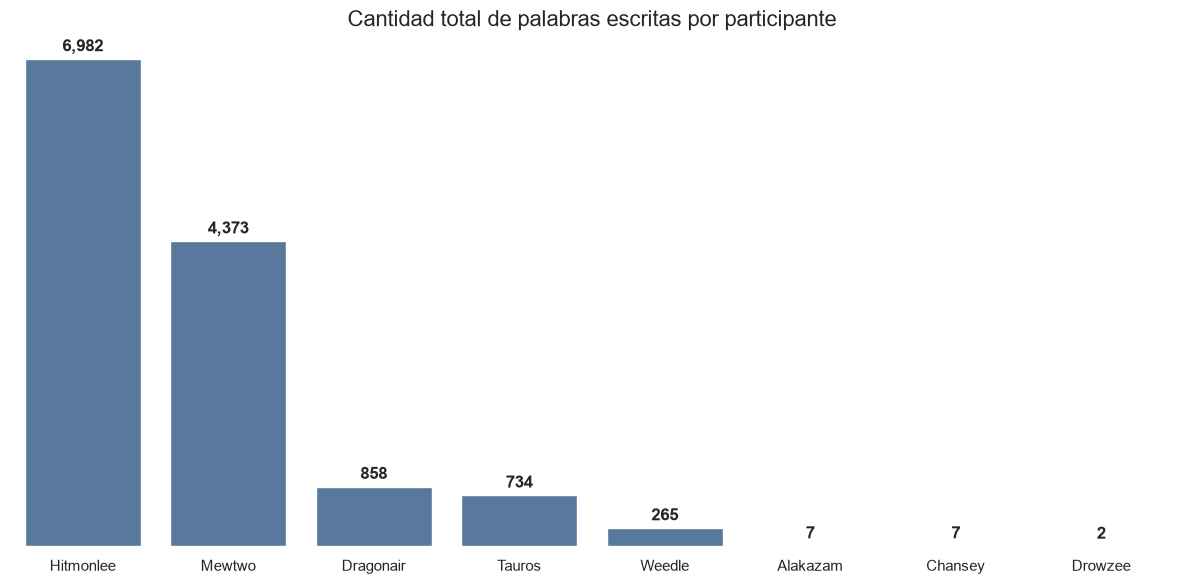

In [21]:
df_plot = (
    estadisticas_palabras
    .sort_values("total", ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_plot,
    x="nombre",
    y="total",
    color="#4E79A7"  # Azul tipo Tableau
)

ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"{x:,.0f}",
    padding=3,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])

plt.title(
    "Cantidad total de palabras escritas por participante",
    fontsize=16
)

sns.despine(
    left=True,
    bottom=True
)

plt.tight_layout()
plt.show()

`Hitmonlee` es quien más enviado más palabras en el periodo analizado, y también es quien más mensajes ha enviado y ha enviado el mensaje más largo.

### 3.1. _¿Quién envía más emojis? ¿Y más stickers?_

Un punto importante a aclarar es que la herramienta de exportar chats de whatsapp te muestra ese tipo de mensajes multimedia como `<Multimedia omitido>`, así que en este análisis se tendrá que agrupar todo tipo de multimedia bajo esa categoría.

In [22]:
df_map[df_map["mensaje"] == "<Multimedia omitido>"].groupby("nombre").size().sort_values(ascending=False)


nombre
Hitmonlee    157
Dragonair     23
Tauros        11
Mewtwo         6
Alakazam       3
Drowzee        1
Weedle         1
dtype: int64

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

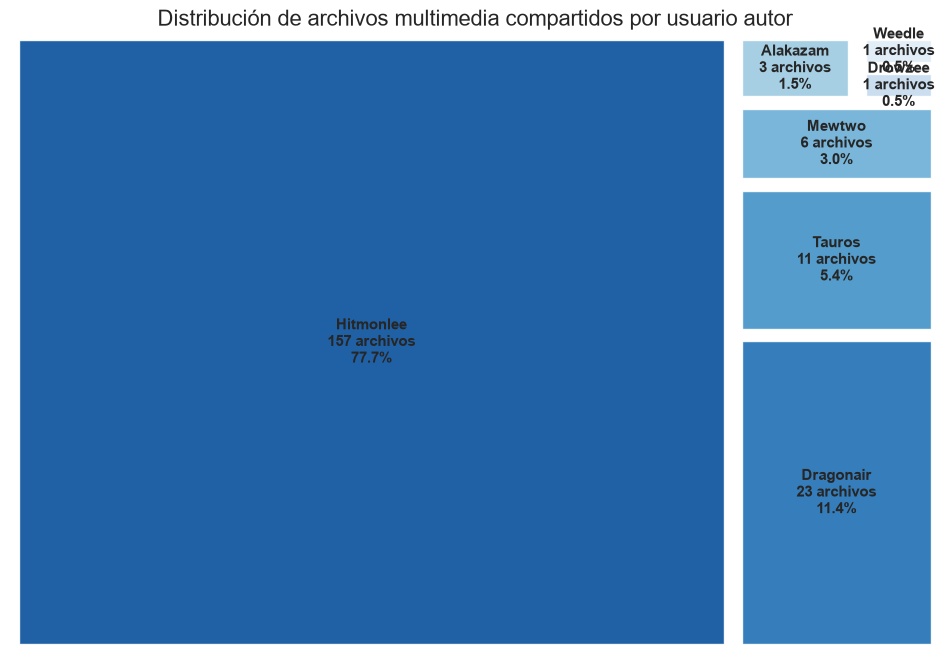

In [23]:
# Conteo de multimedia por usuario
df_multimedia = (
    df_map[df_map["mensaje"] == "<Multimedia omitido>"]
    .groupby("nombre")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="cantidad")
)

# Porcentaje
df_multimedia["porcentaje"] = (
    df_multimedia["cantidad"]
    / df_multimedia["cantidad"].sum()
    * 100
)

# Etiquetas
labels = [
    f"{nombre}\n{cantidad:,} archivos\n{porcentaje:.1f}%"
    for nombre, cantidad, porcentaje in zip(
        df_multimedia["nombre"],
        df_multimedia["cantidad"],
        df_multimedia["porcentaje"]
    )
]

# Paleta azul
colores = sns.color_palette(
    "Blues",
    n_colors=len(df_multimedia)
)[::-1]

plt.figure(figsize=(12, 8))

plt.title("Distribución de archivos multimedia compartidos por usuario autor", fontsize=16)

squarify.plot(
    sizes=df_multimedia["cantidad"],
    label=labels,
    color=colores,
    alpha=0.9,
    pad=True,
    text_kwargs={
        "fontsize": 11,
        "fontweight": "bold"
    }
)

plt.axis("off")

En general, `Hitmonlee` es el usuario que más contenido multimedia manda al grupo. Otro aspecto curioso es que `Mewtwo` manda muchos mensajes, pero casi no comparte archivos multimedia, delegando así su segundo lugar a `Dragonair.`

### _4.0. ¿Que días de la semana se mandan más mensajes y cuales menos? ¿Hay un patron semanal?_ 

In [24]:
mensajes_hora = (
    df_map
    .set_index("datetime")
    .resample("1h")
    .size()
    .reset_index(name="cantidad")
)

mensajes_hora.head()

,datetime,cantidad
0,2026-03-26 14:00:00-07:00,4
1,2026-03-26 15:00:00-07:00,10
2,2026-03-26 16:00:00-07:00,0
3,2026-03-26 17:00:00-07:00,0
4,2026-03-26 18:00:00-07:00,0


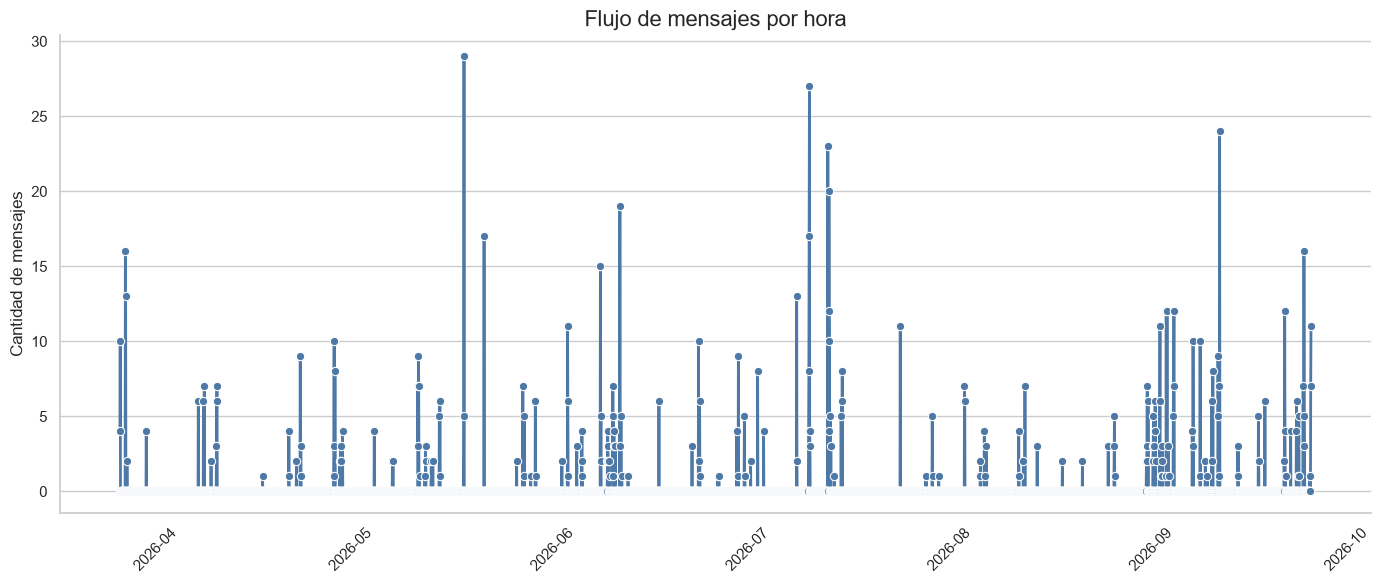

In [26]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=mensajes_hora,
    x="datetime",
    y="cantidad",
    marker="o",
    color="#4E79A7",
    linewidth=2
)

ax.set_title(
    "Flujo de mensajes por hora",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("Cantidad de mensajes")

ax.grid(
    axis="x",
    visible=False
)

# Formato de fechas en eje X
plt.xticks(rotation=45)

# Quitar bordes innecesarios
sns.despine(
    left=False,
    bottom=False
)

plt.tight_layout()
plt.show()

A esta resolución no se alcanza sacar ninguna conclusión clara. 

¿Cómo se vería si el análisis es por semana? ¿Qué información podríamos rescatar?

In [27]:
mensajes_dia = (
    df_map
    .set_index("datetime")
    .resample("1d")
    .size()
    .reset_index(name="cantidad")
)

mensajes_dia.head()

C:\Users\ivans\AppData\Local\Temp\ipykernel_18180\592197624.py:4: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .resample("1d")


,datetime,cantidad
0,2026-03-26 00:00:00-07:00,14
1,2026-03-27 00:00:00-07:00,31
2,2026-03-28 00:00:00-07:00,0
3,2026-03-29 00:00:00-07:00,0
4,2026-03-30 00:00:00-07:00,4


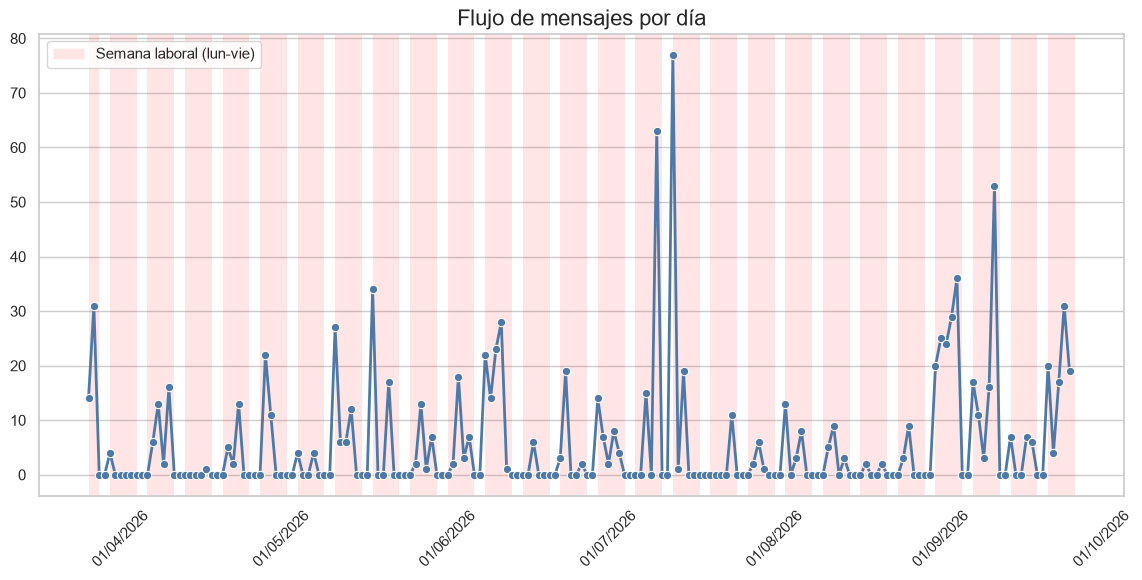

In [31]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(14, 6))

# Línea principal
sns.lineplot(
    data=mensajes_dia,
    x="datetime",
    y="cantidad",
    marker="o",
    color="#4E79A7",
    linewidth=2,
    ax=ax
)

# Fondo para días laborales
for fecha in mensajes_dia["datetime"]:
    if fecha.weekday() < 5:
        ax.axvspan(
            fecha,
            fecha + pd.Timedelta(days=1),
            color="red",
            alpha=0.10,
            linewidth=0
        )

# Leyenda para el sombreado
leyenda_laboral = Patch(
    facecolor="red",
    alpha=0.10,
    label="Semana laboral (lun-vie)"
)

ax.legend(
    handles=[leyenda_laboral],
    frameon=True
)

# Formato del eje X
ax.xaxis.set_major_formatter(
    DateFormatter("%d/%m/%Y")
)

ax.tick_params(
    axis="x",
    rotation=45
)

# Títulos y ejes
ax.set_title(
    "Flujo de mensajes por día",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("")

# Solo cuadrícula horizontal
ax.grid(
    axis="x",
    visible=False
)

En este punto se observa que los fines de semana parece ser que la acitivdad del grupo cae significativamente. Intentemos acercarnos un poco más para ver el comportamiento por día.

In [44]:
# Cantidad de mensajes por fecha
mensajes_fecha = (
    df_map
    .set_index("datetime")
    .resample("1D")
    .size()
    .reset_index(name="cantidad")
)

# Día de la semana
mensajes_fecha["dia_semana"] = mensajes_fecha["datetime"].dt.day_name()

promedio_dia = (
    mensajes_fecha
    .groupby("dia_semana")["cantidad"]
    .mean()
    .reset_index(name="promedio_mensajes")
)

promedio_dia

,dia_semana,promedio_mensajes
0,Friday,9.703704
1,Monday,10.076923
2,Saturday,0.000000
3,Sunday,0.000000
4,Thursday,7.185185
5,Tuesday,5.230769
6,Wednesday,7.653846


In [45]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

promedio_dia["dia_semana"] = pd.Categorical(
    promedio_dia["dia_semana"],
    categories=orden_dias,
    ordered=True
)

promedio_dia = promedio_dia.sort_values("dia_semana")

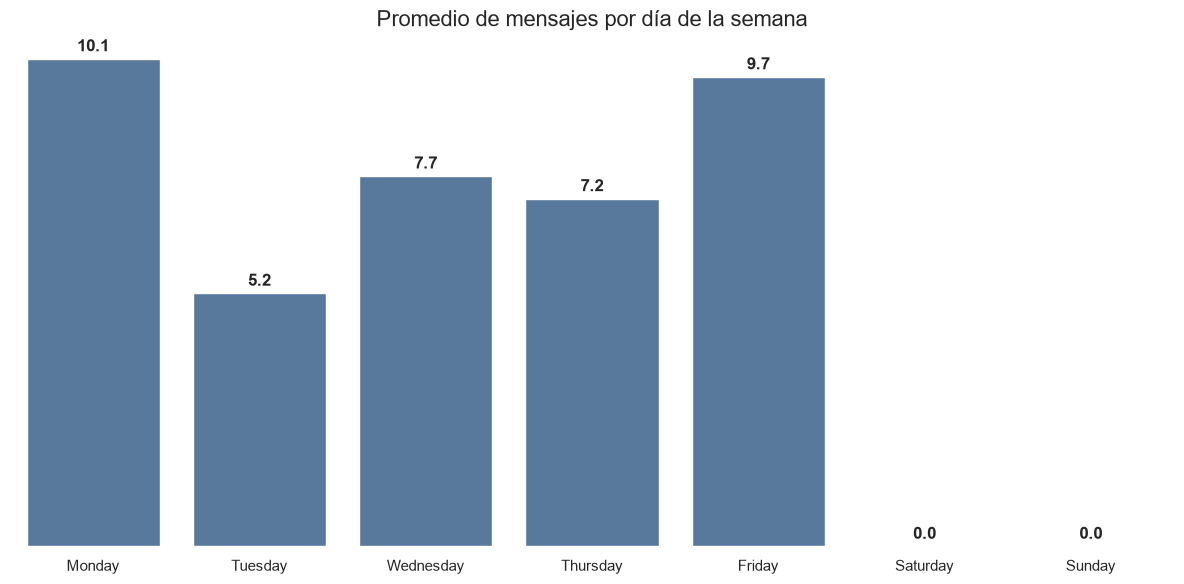

In [46]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=promedio_dia,
    x="dia_semana",
    y="promedio_mensajes",
    color="#4E79A7",
    ax=ax
)

# Data labels con un decimal
ax.bar_label(
    ax.containers[0],
    fmt="%.1f",
    padding=3,
    fontweight="bold"
)

# Quitar títulos y valores del eje Y
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])

# Quitar cuadrícula horizontal porque ya tenemos labels
ax.grid(axis="y", visible=False)

# Título
ax.set_title(
    "Promedio de mensajes por día de la semana",
    fontsize=16
)

sns.despine(
    left=True,
    bottom=True
)

plt.tight_layout()
plt.show()

En efecto: los sábados y domingos se respetan de manera religiosa, mostrando que no se este grupo ni se toca... fuera de eso, parece que el día con menos actividad es el martes, ¿Podría ser quizás por reuniones calendarizadas por parte de uno de los equipos? quizás al analizar los mensajes por hora se obtenga una respuesta más clara.

In [47]:
# Cantidad de mensajes por fecha y hora
mensajes_fecha_hora = (
    df_map
    .set_index("datetime")
    .resample("1h")
    .size()
    .reset_index(name="cantidad")
)

# Extraer hora del día
mensajes_fecha_hora["hora"] = mensajes_fecha_hora["datetime"].dt.hour

# Promedio para cada una de las 24 horas
promedio_hora = (
    mensajes_fecha_hora
    .groupby("hora")["cantidad"]
    .mean()
    .reindex(range(24), fill_value=0)
    .reset_index(name="promedio_mensajes")
)

promedio_hora

,hora,promedio_mensajes
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000000
5,5,0.000000
6,6,0.000000
7,7,0.049180
8,8,0.109290
9,9,0.595628


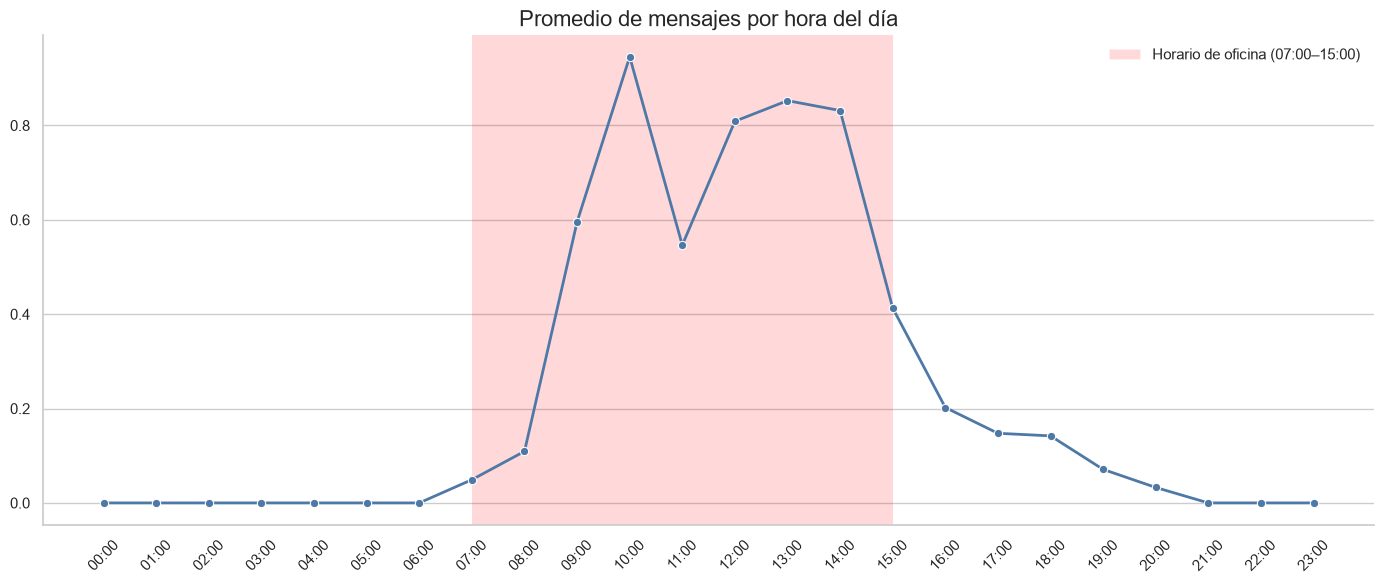

In [48]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(14, 6))

# Línea principal
sns.lineplot(
    data=promedio_hora,
    x="hora",
    y="promedio_mensajes",
    marker="o",
    color="#4E79A7",
    linewidth=2,
    ax=ax
)

# Sombrear horario de oficina: 07:00 - 15:00
ax.axvspan(
    7,
    15,
    color="red",
    alpha=0.15,
    linewidth=0
)

# Leyenda para el horario de oficina
leyenda_oficina = Patch(
    facecolor="red",
    alpha=0.15,
    label="Horario de oficina (07:00–15:00)"
)

ax.legend(
    handles=[leyenda_oficina],
    frameon=False
)

# Mostrar las 24 horas
ax.set_xticks(range(24))
ax.set_xticklabels(
    [f"{h:02d}:00" for h in range(24)],
    rotation=45
)

# Título y ejes
ax.set_title(
    "Promedio de mensajes por hora del día",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("")

# Solo cuadrícula horizontal
ax.grid(
    axis="x",
    visible=False
)


sns.despine()

plt.tight_layout()
plt.show()

La gran mayoría de actividad en el grupo se realiza dentro del horario laboral que abarca de 7 de la mañana a 3 de la tarde. Sin embargo, también se registra actividad después de la hora de salida.

Otro aspecto curioso es la caída que se registra alrededor de las 11:00, así que se puede decir que el martes a las 11:00 de la mañana es el día más tranquilo respecto a este grupo; no obstante, se observa un pico de mensajes ya acercándose a la hora de salida, ¿será que salen temas de relevancia ya casi dando la hora de salida?

### _5.0. ¿Que palabras son las más usadas por cada usuario?_

In [49]:
nlp = spacy.load("es_core_news_sm")

top_palabras = {}

for nombre, grupo in df_texto.groupby("nombre"):

    texto = " ".join(
        grupo["mensaje"]
        .dropna()
        .astype(str)
        .tolist()
    )

    doc = nlp(texto)

    palabras = [
        token.lemma_.lower()
        for token in doc
        if (
            token.is_alpha
            and not token.is_stop
            and not token.is_punct
            and not token.is_space
        )
    ]

    top_palabras[nombre] = Counter(palabras).most_common(1)

top_palabras

{'Alakazam': [('capacitación', 1)],
 'Chansey': [('opción', 1)],
 'Dragonair': [('gracias', 24)],
 'Drowzee': [('okey', 1)],
 'Hitmonlee': [('sistema', 45)],
 'Mewtwo': [('reunión', 29)],
 'Tauros': [('checar', 10)],
 'Weedle': [('clave', 4)]}

In [50]:
# Convertir el diccionario a DataFrame
datos = []

for usuario, palabras in top_palabras.items():
    for palabra, frecuencia in palabras:
        datos.append({
            "usuario": usuario,
            "palabra": palabra,
            "frecuencia": frecuencia
        })

df_top_palabras = pd.DataFrame(datos)

df_top_palabras.head()

,usuario,palabra,frecuencia
0,Alakazam,capacitación,1
1,Chansey,opción,1
2,Dragonair,gracias,24
3,Drowzee,okey,1
4,Hitmonlee,sistema,45


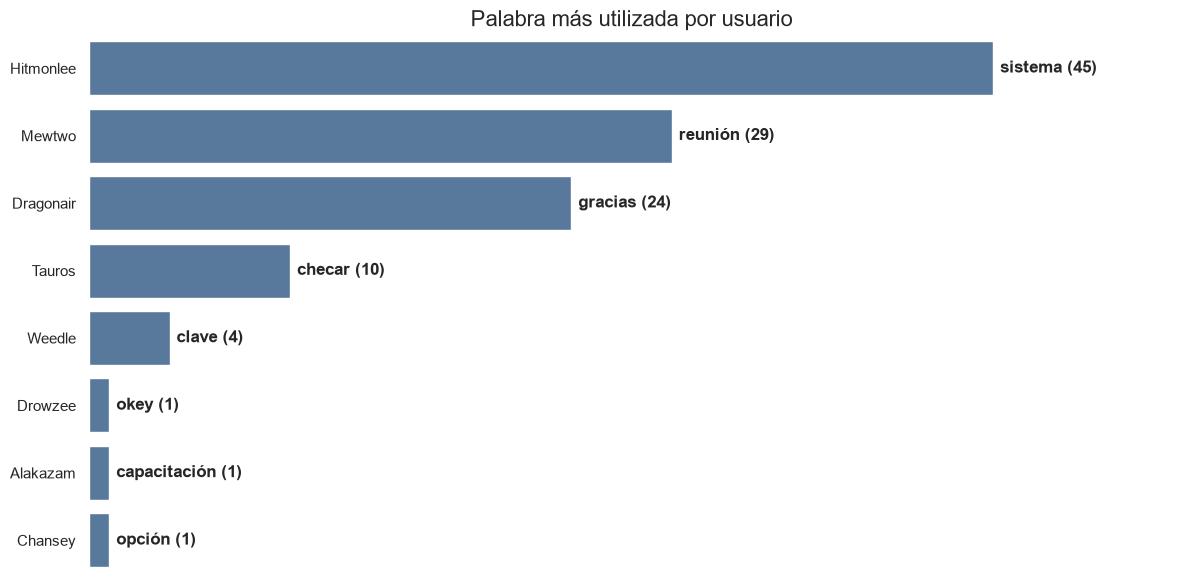

In [53]:
# Ordenar para gráfica horizontal
df_top_palabras = df_top_palabras.sort_values(
    "frecuencia",
    ascending=False
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_top_palabras,
    x="frecuencia",
    y="usuario",
    color="#4E79A7",
    ax=ax
)

# Labels: palabra (frecuencia)
labels = [
    f"{palabra} ({frecuencia:,})"
    for palabra, frecuencia in zip(
        df_top_palabras["palabra"],
        df_top_palabras["frecuencia"]
    )
]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=5,
    fontweight="bold"
)

# Título y ejes
ax.set_title(
    "Palabra más utilizada por usuario",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("")

# Quitar valores del eje X
ax.set_xticks([])

# Quitar cuadrícula
ax.grid(
    axis="x",
    visible=False
)

sns.despine(
    left=True,
    bottom=True
)

# Espacio adicional para que no se corten los labels
ax.margins(x=0.20)

plt.tight_layout()
plt.show()

Parece que a `Mewtwo` le gusta agendar muchas reuniones, y parece que `Hitmonlee` no se puede sacar el sistema de la boca. También llama atención que la palabra `gracias` aparece constantemente, pero no la palabra `por favor`.

### _5.1. ¿Que palabras son las más usadas en general en el grupo?_

In [54]:
# Unir todos los mensajes
texto_chat = " ".join(
    df_texto["mensaje"]
    .dropna()
    .astype(str)
)

# Procesar con spaCy
doc = nlp(texto_chat)

# Filtrar y lematizar
palabras = [
    token.lemma_.lower()
    for token in doc
    if (
        token.is_alpha
        and not token.is_stop
        and not token.is_punct
        and not token.is_space
    )
]

# Calcular frecuencias
frecuencias = Counter(palabras)

frecuencias.most_common(20)

[('sistema', 66),
 ('información', 57),
 ('catálogo', 55),
 ('paaas', 54),
 ('gracias', 49),
 ('laura', 48),
 ('reunión', 46),
 ('plataforma', 42),
 ('enviar', 42),
 ('poder', 40),
 ('ok', 39),
 ('favor', 38),
 ('quedar', 37),
 ('usuario', 33),
 ('apoyar', 33),
 ('precio', 33),
 ('código', 32),
 ('alta', 32),
 ('programa', 32),
 ('momento', 30)]

In [55]:
excluir = {
    "hola",
    "de",
    "y",
    "para",
    "la",
    "a",
    "laura",
    "ivo",
    "diana",
    "erika"
    #   ...
}

frecuencias_limpias = {
    palabra: frecuencia
    for palabra, frecuencia in frecuencias.items()
    if palabra not in excluir
}

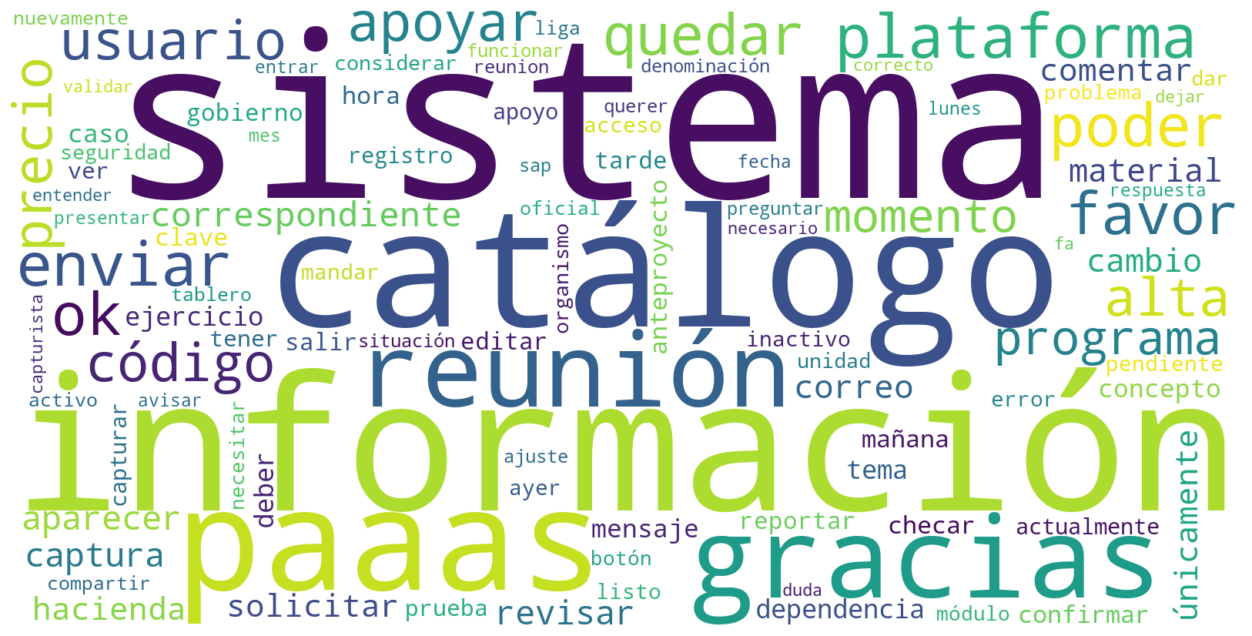

In [58]:
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=100,
    collocations=False
).generate_from_frequencies(frecuencias_limpias)

plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.show()

La palabra más utilizada es `sistema`, seguido de `información` y `catálogo`. En la nube de palabras, la palabra "favor" está significativamente reducida en tamaño al comparación del "gracias"

#### 6. ¿Cuales son los adjetivos más usados?

In [59]:
# Unir todos los mensajes
texto_chat = " ".join(
    df_texto["mensaje"]
    .dropna()
    .astype(str)
)

# Procesar con spaCy
doc = nlp(texto_chat)

# Extraer únicamente adjetivos
adjetivos = [
    token.lemma_.lower()
    for token in doc
    if (
        token.pos_ == "ADJ"
        and token.is_alpha
        and not token.is_stop
    )
]

# Contar frecuencias
frecuencia_adjetivos = Counter(adjetivos)

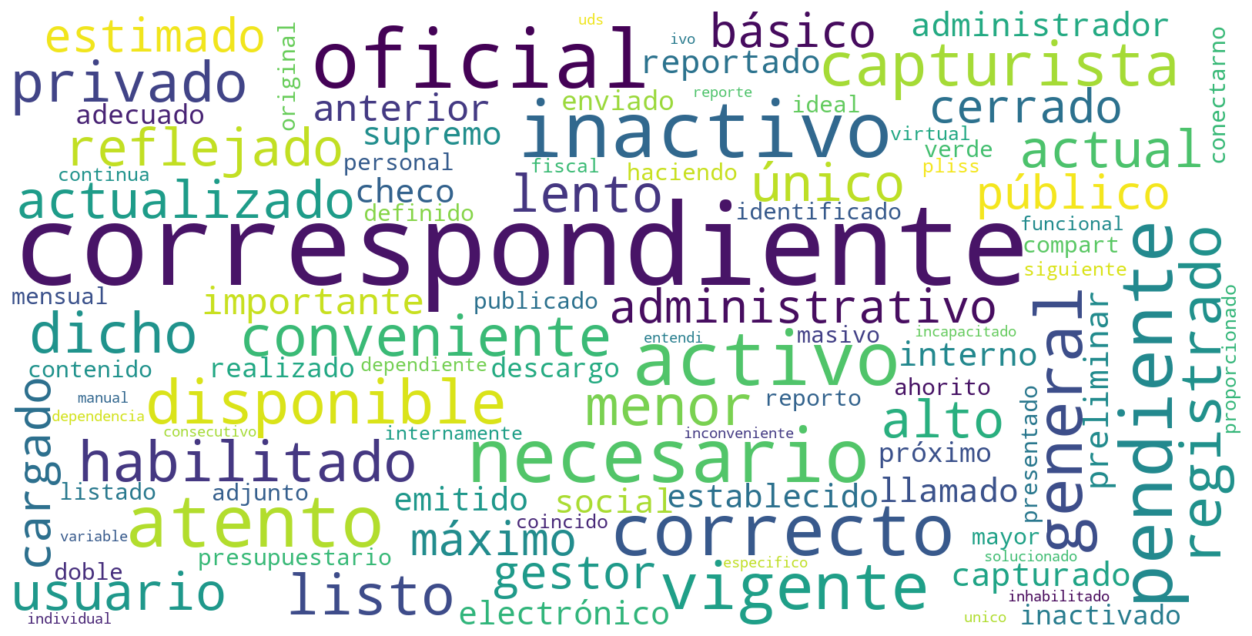

In [60]:
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=100,
    collocations=False
).generate_from_frequencies(frecuencia_adjetivos)

plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.show()

Palabras como `Correspondiente`, `oficial` o `inactivo` son las que más resaltan,

---

## ¿Qué otras preguntas interesantes puedes responder con los datos que tienes? ¿Qué otras gráficas o análisis puedes hacer?

### 6.1. _Qué usuarios fueron mencioados en más ocasiones en el grupo, ya sea por una emergencia o por una revisión que era importante que revisaran a la brevedad?_


In [68]:
# Extraer todas las menciones de cada mensaje
menciones = (
    df_texto["mensaje"]
    .str.findall(r"@\['([^']+)'\]")
    .explode()
    .dropna()
)

menciones.head()

0     Hitmonlee
0        Weedle
30       Tauros
74    Hitmonlee
74    Dragonair
Name: mensaje, dtype: str

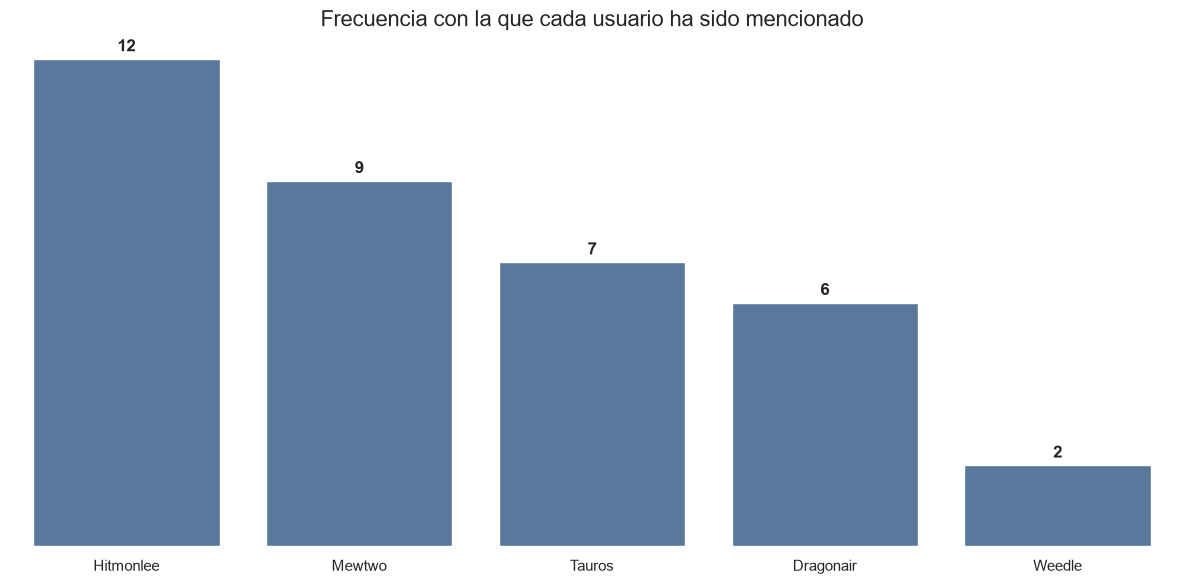

In [69]:
# Conteo de menciones
conteo_menciones = (
    menciones
    .value_counts()
    .rename_axis("usuario")
    .reset_index(name="menciones")
    .sort_values("menciones", ascending=False)
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=conteo_menciones,
    x="usuario",
    y="menciones",
    color="#4E79A7",
    ax=ax
)

# Cantidad sobre cada barra
ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"{x:,.0f}",
    padding=3,
    fontweight="bold"
)

ax.set_title(
    "Frecuencia con la que cada usuario ha sido mencionado",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("")

# Ya mostramos los valores encima de las barras
ax.set_yticks([])
ax.grid(axis="y", visible=False)

sns.despine(
    left=True,
    bottom=True
)

plt.tight_layout()
plt.show()

`Hitmonlee` es el usuario más mencionado seguido por `Mewtwo`. Con este análisis podemos estar seguros de la interacción activa que hay entre estos dos usuarios, parece que son los representantes de ambos equipos involucrados en este proyecto. 

### 6.2. Quién es el usuario más  `cortez` en el grupo? Aquél acostumbrado a ser más educado y a usar palabras como `por favor` y `gracias`

In [73]:
expresiones_cortesia = [
    r"\bpor favor\b",
    r"\bporfavor\b",
    r"\bfavor\b",
    r"\bgracias\b",
    r"\bagradezco\b",
    r"\bagradecería\b",
    r"\bporfa\b",
    r"\bbuen día\b",
    r"\bbuenas tardes\b",
    r"\bbuenas noches\b",
]

patron = re.compile(
    "|".join(expresiones_cortesia),
    flags=re.IGNORECASE
)

df_cortesia = df_texto.copy()

df_cortesia["num_cortesia"] = (
    df_cortesia["mensaje"]
    .fillna("")
    .apply(lambda texto: len(patron.findall(texto)))
)

conteo_cortesia = (
    df_cortesia
    .groupby("nombre")["num_cortesia"]
    .sum()
    .sort_values(ascending=False)
)

In [74]:
resumen_cortesia = (
    df_cortesia
    .groupby("nombre")
    .agg(
        mensajes=("mensaje", "count"),
        expresiones_cortesia=("num_cortesia", "sum")
    )
)

resumen_cortesia["cortesia_por_100_mensajes"] = (
    resumen_cortesia["expresiones_cortesia"]
    / resumen_cortesia["mensajes"]
    * 100
)

resumen_cortesia.sort_values(
    "cortesia_por_100_mensajes",
    ascending=False
)

,mensajes,expresiones_cortesia,cortesia_por_100_mensajes
nombre,,,
Weedle,7,5,71.428571
Dragonair,72,36,50.000000
Hitmonlee,437,82,18.764302
Mewtwo,215,25,11.627907
Tauros,116,10,8.620690
Drowzee,2,0,0.000000
Alakazam,1,0,0.000000
Chansey,1,0,0.000000


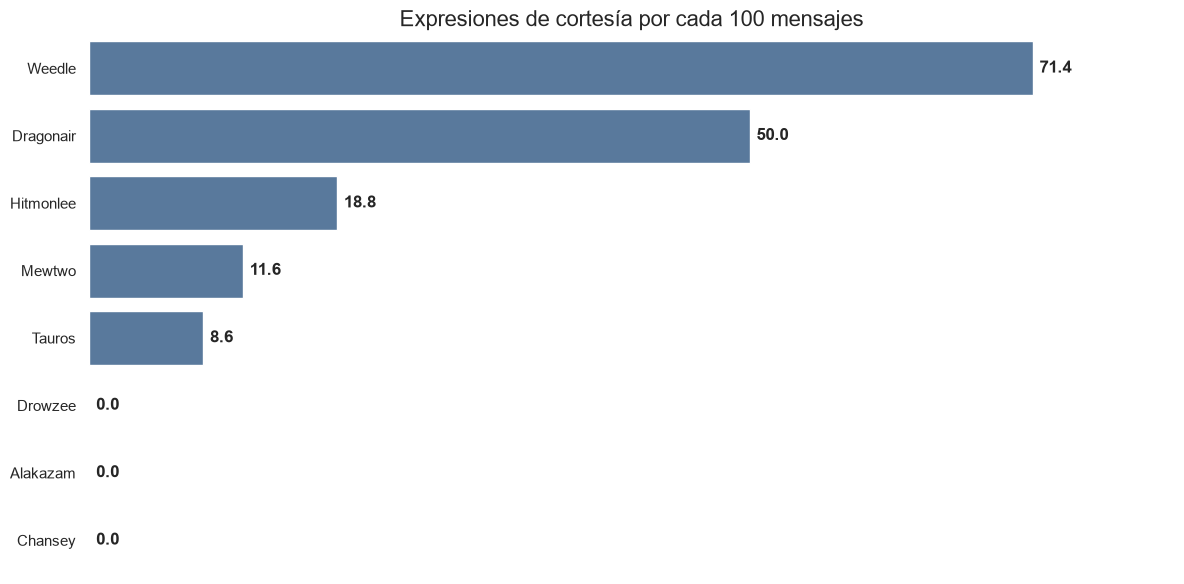

In [75]:
# Pasar nombre del índice a columna
df_plot = (
    resumen_cortesia
    .reset_index()
    .sort_values("cortesia_por_100_mensajes", ascending=False)
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_plot,
    x="cortesia_por_100_mensajes",
    y="nombre",
    color="#4E79A7",
    ax=ax
)

# Mostrar valor al final de cada barra
ax.bar_label(
    ax.containers[0],
    fmt="%.1f",
    padding=5,
    fontweight="bold"
)

ax.set_title(
    "Expresiones de cortesía por cada 100 mensajes",
    fontsize=16
)

ax.set_xlabel("")
ax.set_ylabel("")

# Quitar valores y cuadrícula del eje X
ax.set_xticks([])
ax.grid(axis="x", visible=False)

# Espacio para las etiquetas
ax.margins(x=0.15)

sns.despine(
    left=True,
    bottom=True
)

plt.tight_layout()
plt.show()

Parece que `Weedle` a pesar de no participar mucho en el chat, cuando lo hace actúa de una manera muy cordial. Lo mismo no se puede decir de `Hitmonlee`, quien a pesar de ser con diferencia el usuario con más mensajes enviados, se queda muy atrás al comparar su forma de expresar con la de `Weedle` o `Dragonair`.

---
## Conclusiones generales
Parece que la dinámica de este grupo se centra mucho en la interacción entre dos usuarios que discuten temas de un sistema, de tener reuniones para aclarar temas o incluso hablar sobre unos códigos o de información para esta área operativa, o al menos eso hacen de lunes a viernes porque es cuestión de dar con la hora de salida y mágicamente el grupo queda inactivo hasta que vuelva a ser lunes. Parece que se respeta más esos días que el mandar mensajes fuera del horario laboral establecido.

Si hay una moraleja que puedo sacar de este análisis es la siguiente: recuerden siempre ser educados.